In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [2]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final9_2.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [3]:
# 데이터를 읽어온다.
train_df = pd.read_csv('train_VIF5.csv')
test_df = pd.read_csv('test_VIF5.csv')

display(train_df)
display(test_df)

,이용금액_R3M_신용체크,소지카드수_이용가능_신용,Life_Stage,_1순위카드이용금액,RV전환가능여부,자발한도감액횟수_R12M,한도증액횟수_R12M,카드론동의여부,한도심사요청건수,카드이용한도금액_B2M,...,이용후경과월_할부_무이자,혜택수혜금액,할인건수_R3M,대표청구지고객주소구분코드,대표결제방법코드,청구금액_R6M,월중평잔_일시불,방문횟수_PC_R6M,이용메뉴건수_ARS_R6M,인입횟수_ARS_R6M
0,196,1,자녀성장(2),3681,N,0회,0회,Y,0회,19723,...,2,0,1회 이상,미확인,자동이체,88693,1503,1회 이상,10회 이상,10회 이상
1,13475,1,자녀성장(1),13323,Z,0회,0회,Y,0회,9998,...,9,0,1회 이상,주거지,자동이체,16861,4447,1회 이상,1회 이상,1회 이상
2,23988,1,자녀출산기,24493,N,0회,0회,Y,0회,77975,...,0,50,1회 이상,미확인,자동이체,165221,5540,10회 이상,1회 이상,1회 이상
3,3904,2,자녀성장(2),5933,N,0회,0회,Y,0회,19226,...,1,2,1회 이상,주거지,자동이체,127371,606,1회 이상,10회 이상,10회 이상
4,1190,1,자녀성장(1),0,Z,0회,0회,Y,0회,168681,...,12,0,1회 이상,주거지,자동이체,155,0,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,10755,1,노년생활,5640,Z,0회,0회,Y,0회,21152,...,12,0,1회 이상,주거지,자동이체,0,0,1회 이상,1회 이상,1회 이상
2399996,27636,1,자녀성장(2),26357,Z,0회,1회이상,Y,0회,78140,...,9,53,1회 이상,미확인,자동이체,99849,5515,1회 이상,1회 이상,1회 이상
2399997,23187,1,자녀출산기,17171,N,0회,0회,Y,0회,63374,...,1,0,1회 이상,회사,자동이체,41073,3046,1회 이상,1회 이상,1회 이상
2399998,0,1,자녀성장(1),0,Z,0회,0회,Y,0회,10001,...,12,0,1회 이상,주거지,자동이체,0,0,1회 이상,1회 이상,1회 이상


,이용금액_R3M_신용체크,소지카드수_이용가능_신용,Life_Stage,_1순위카드이용금액,RV전환가능여부,자발한도감액횟수_R12M,한도증액횟수_R12M,카드론동의여부,한도심사요청건수,카드이용한도금액_B2M,...,이용후경과월_할부_무이자,혜택수혜금액,할인건수_R3M,대표청구지고객주소구분코드,대표결제방법코드,청구금액_R6M,월중평잔_일시불,방문횟수_PC_R6M,이용메뉴건수_ARS_R6M,인입횟수_ARS_R6M
0,21458,2,자녀성장(1),13852,Z,0회,0회,N,0회,50006,...,12,56,1회 이상,미확인,자동이체,22151,5187,1회 이상,1회 이상,1회 이상
1,18681,1,자녀독립기,11065,N,0회,0회,Y,0회,50003,...,0,0,1회 이상,미확인,자동이체,32878,865,1회 이상,1회 이상,1회 이상
2,40758,2,자녀성장(1),27071,Z,0회,1회이상,Y,0회,100056,...,3,50,1회 이상,미확인,자동이체,71867,5591,1회 이상,1회 이상,1회 이상
3,5255,1,자녀성장(1),4827,Z,0회,0회,Y,0회,19693,...,2,1,1회 이상,주거지,자동이체,4986,1545,1회 이상,1회 이상,1회 이상
4,16148,1,자녀성장(1),8011,Z,0회,0회,Y,0회,3924,...,0,0,1회 이상,주거지,자동이체,10758,1462,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,노년생활,0,NaN,0회,0회,Y,0회,0,...,12,0,1회 이상,회사,자동이체,0,0,1회 이상,1회 이상,1회 이상
599996,3110,1,자녀출산기,1231,Z,0회,0회,Y,0회,49990,...,12,49,1회 이상,주거지,자동이체,2237,256,1회 이상,1회 이상,1회 이상
599997,0,1,자녀성장(1),0,Z,0회,0회,Y,0회,30004,...,12,0,1회 이상,미확인,자동이체,0,0,1회 이상,1회 이상,1회 이상
599998,173263,3,가족구축기,63592,Z,0회,0회,Y,0회,37139,...,2,0,1회 이상,미확인,자동이체,108420,14005,1회 이상,1회 이상,1회 이상


In [4]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,이용금액_R3M_신용체크,소지카드수_이용가능_신용,Life_Stage,_1순위카드이용금액,RV전환가능여부,자발한도감액횟수_R12M,한도증액횟수_R12M,카드론동의여부,한도심사요청건수,카드이용한도금액_B2M,...,이용후경과월_할부_무이자,혜택수혜금액,할인건수_R3M,대표청구지고객주소구분코드,대표결제방법코드,청구금액_R6M,월중평잔_일시불,방문횟수_PC_R6M,이용메뉴건수_ARS_R6M,인입횟수_ARS_R6M
0,196,1,자녀성장(2),3681,N,0회,0회,Y,0회,19723,...,2,0,1회 이상,미확인,자동이체,88693,1503,1회 이상,10회 이상,10회 이상
1,13475,1,자녀성장(1),13323,Z,0회,0회,Y,0회,9998,...,9,0,1회 이상,주거지,자동이체,16861,4447,1회 이상,1회 이상,1회 이상
2,23988,1,자녀출산기,24493,N,0회,0회,Y,0회,77975,...,0,50,1회 이상,미확인,자동이체,165221,5540,10회 이상,1회 이상,1회 이상
3,3904,2,자녀성장(2),5933,N,0회,0회,Y,0회,19226,...,1,2,1회 이상,주거지,자동이체,127371,606,1회 이상,10회 이상,10회 이상
4,1190,1,자녀성장(1),0,Z,0회,0회,Y,0회,168681,...,12,0,1회 이상,주거지,자동이체,155,0,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,0,0,노년생활,0,NaN,0회,0회,Y,0회,0,...,12,0,1회 이상,회사,자동이체,0,0,1회 이상,1회 이상,1회 이상
2999996,3110,1,자녀출산기,1231,Z,0회,0회,Y,0회,49990,...,12,49,1회 이상,주거지,자동이체,2237,256,1회 이상,1회 이상,1회 이상
2999997,0,1,자녀성장(1),0,Z,0회,0회,Y,0회,30004,...,12,0,1회 이상,미확인,자동이체,0,0,1회 이상,1회 이상,1회 이상
2999998,173263,3,가족구축기,63592,Z,0회,0회,Y,0회,37139,...,2,0,1회 이상,미확인,자동이체,108420,14005,1회 이상,1회 이상,1회 이상


In [5]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 26 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   이용금액_R3M_신용체크   int64 
 1   소지카드수_이용가능_신용   int64 
 2   Life_Stage      object
 3   _1순위카드이용금액      int64 
 4   RV전환가능여부        object
 5   자발한도감액횟수_R12M   object
 6   한도증액횟수_R12M     object
 7   카드론동의여부         object
 8   한도심사요청건수        object
 9   카드이용한도금액_B2M    int64 
 10  최대이용금액_할부_R12M  int64 
 11  이용금액_일시불_R12M   int64 
 12  _3순위업종_이용금액     int64 
 13  이용금액_오프라인_B0M   int64 
 14  연체입금원금_B0M      int64 
 15  이용금액대           object
 16  이용후경과월_할부_무이자   int64 
 17  혜택수혜금액          int64 
 18  할인건수_R3M        object
 19  대표청구지고객주소구분코드   object
 20  대표결제방법코드        object
 21  청구금액_R6M        int64 
 22  월중평잔_일시불        int64 
 23  방문횟수_PC_R6M     object
 24  이용메뉴건수_ARS_R6M  object
 25  인입횟수_ARS_R6M    object
dtypes: int64(13), object(13)
memory usage: 595.1+ MB


In [6]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [7]:
# LabelEncoder 학습
Encoder2 = LabelEncoder()
Encoder3 = LabelEncoder()
Encoder4 = LabelEncoder()
Encoder5 = LabelEncoder()
Encoder6 = LabelEncoder()
Encoder7 = LabelEncoder()
Encoder8 = LabelEncoder()
Encoder9 = LabelEncoder()
Encoder10 = LabelEncoder()
Encoder11 = LabelEncoder()
Encoder12 = LabelEncoder()
Encoder13 = LabelEncoder()
Encoder14 = LabelEncoder()

Encoder2.fit(all_df['RV전환가능여부'])
Encoder3.fit(all_df['자발한도감액횟수_R12M'])
Encoder4.fit(all_df['한도증액횟수_R12M'])
Encoder5.fit(all_df['카드론동의여부'])
Encoder6.fit(all_df['한도심사요청건수'])
Encoder7.fit(all_df['이용금액대'])
Encoder8.fit(all_df['할인건수_R3M'])
Encoder9.fit(all_df['대표결제방법코드'])
Encoder10.fit(all_df['방문횟수_PC_R6M'])
Encoder11.fit(all_df['이용메뉴건수_ARS_R6M'])
Encoder12.fit(all_df['인입횟수_ARS_R6M'])
Encoder13.fit(all_df['대표청구지고객주소구분코드'])
Encoder14.fit(all_df['Life_Stage'])

LabelEncoder()

In [8]:
train_df['RV전환가능여부'] = Encoder2.transform(train_df['RV전환가능여부'])
train_df['자발한도감액횟수_R12M'] = Encoder3.transform(train_df['자발한도감액횟수_R12M'])
train_df['한도증액횟수_R12M'] = Encoder4.transform(train_df['한도증액횟수_R12M'])
train_df['카드론동의여부'] = Encoder5.transform(train_df['카드론동의여부'])
train_df['한도심사요청건수'] = Encoder6.transform(train_df['한도심사요청건수'])
train_df['이용금액대'] = Encoder7.transform(train_df['이용금액대'])
train_df['할인건수_R3M'] = Encoder8.transform(train_df['할인건수_R3M'])
train_df['대표결제방법코드'] = Encoder9.transform(train_df['대표결제방법코드'])
train_df['방문횟수_PC_R6M'] = Encoder10.transform(train_df['방문횟수_PC_R6M'])
train_df['이용메뉴건수_ARS_R6M'] = Encoder11.transform(train_df['이용메뉴건수_ARS_R6M'])
train_df['인입횟수_ARS_R6M'] = Encoder12.transform(train_df['인입횟수_ARS_R6M'])
train_df['대표청구지고객주소구분코드'] = Encoder13.transform(train_df['대표청구지고객주소구분코드'])
train_df['Life_Stage'] = Encoder14.transform(train_df['Life_Stage'])

In [9]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(train_df)

,copy,True
,with_mean,True
,with_std,True


In [10]:
train_data['RV전환가능여부'] = Encoder2.transform(train_data['RV전환가능여부'])
train_data['자발한도감액횟수_R12M'] = Encoder3.transform(train_data['자발한도감액횟수_R12M'])
train_data['한도증액횟수_R12M'] = Encoder4.transform(train_data['한도증액횟수_R12M'])
train_data['카드론동의여부'] = Encoder5.transform(train_data['카드론동의여부'])
train_data['한도심사요청건수'] = Encoder6.transform(train_data['한도심사요청건수'])
train_data['이용금액대'] = Encoder7.transform(train_data['이용금액대'])
train_data['할인건수_R3M'] = Encoder8.transform(train_data['할인건수_R3M'])
train_data['대표결제방법코드'] = Encoder9.transform(train_data['대표결제방법코드'])
train_data['방문횟수_PC_R6M'] = Encoder10.transform(train_data['방문횟수_PC_R6M'])
train_data['이용메뉴건수_ARS_R6M'] = Encoder11.transform(train_data['이용메뉴건수_ARS_R6M'])
train_data['인입횟수_ARS_R6M'] = Encoder12.transform(train_data['인입횟수_ARS_R6M'])
train_data['대표청구지고객주소구분코드'] = Encoder13.transform(train_data['대표청구지고객주소구분코드'])
train_data['Life_Stage'] = Encoder14.transform(train_data['Life_Stage'])

In [11]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [12]:
tg_df = pd.concat([
    target1['Segment'],
    target2['Segment'],
    target3['Segment'],
    target4['Segment'],
    target5['Segment'],
    target6['Segment']
])

tg_df = tg_df.reset_index(drop=True).to_frame(name='Segment')
tg_df

,Segment
0,D
1,E
2,C
3,D
4,E
...,...
2399995,E
2399996,D
2399997,C
2399998,E


In [13]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
tg_df['Segment'] = le.fit_transform(tg_df['Segment'])

In [14]:
tg_df2=tg_df.copy()

y_train = tg_df2.loc[train_data.index]
y_val = tg_df2.loc[val_data.index]

In [15]:
# 입력과 결과로 나눈다.
X=train_data
y=y_train

In [16]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-0.6839184 , -0.24668788, -2.00299101, ..., -0.09528426,
         0.08278686,  0.17468495],
       [-0.7285682 , -1.85886015, -1.44581419, ..., -0.09528426,
         0.08278686,  0.17468495],
       [ 1.64613047,  1.36548438,  0.7828931 , ..., -0.09528426,
         0.08278686,  0.17468495],
       ...,
       [-0.33975356, -0.24668788,  0.22571628, ..., -0.09528426,
         0.08278686,  0.17468495],
       [-0.10600881,  1.36548438,  0.7828931 , ..., -0.09528426,
         0.08278686,  0.17468495],
       [-0.73015977, -0.24668788, -1.44581419, ..., -0.09528426,
         0.08278686,  0.17468495]])

In [17]:
train_X = X2
train_y = y

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [18]:
model5 = LGBMClassifier(device='cpu', objective='multiclass', num_class=5, verbose=-1)

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
r1 = cross_val_score(model5, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

f1_score_list.append(r1.mean())
model_name_list.append("LGBMClassifier")

평균 f1 Score : 0.8665072916666666


In [19]:
# CPU 기반 XGBoost 모델
model6 = XGBClassifier(
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# f1_weighted 사용
r2 = cross_val_score(model6, train_X, train_y, scoring='f1_micro', cv=kfold)
print(f'평균 f1 Score : {r2.mean():.4f}')

f1_score_list.append(r2.mean())
model_name_list.append("XGBClassifier")

평균 f1 Score : 0.8778


In [20]:
final_model=model6.fit(train_X, train_y)

In [21]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(model6, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(Encoder2, fp)
    pickle.dump(Encoder3, fp)
    pickle.dump(Encoder4, fp)
    pickle.dump(Encoder5, fp)
    pickle.dump(Encoder6, fp)
    pickle.dump(Encoder7, fp)
    pickle.dump(Encoder8, fp)
    pickle.dump(Encoder9, fp)
    pickle.dump(Encoder10, fp)
    pickle.dump(Encoder11, fp)
    pickle.dump(Encoder12, fp)
    pickle.dump(Encoder13, fp)
    pickle.dump(Encoder14, fp)
    pickle.dump(le, fp)  # ← LabelEncoder 객체 추가

print('저장완료')

저장완료


In [18]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final9_2.dat'
# 예측 결과를 저장할 파일 이름
prediction_path = 'model/final_prediction9_2.csv'

In [19]:
with open(best_model_path, 'rb') as fp :
    model6 = pickle.load(fp)
    scalerX = pickle.load(fp)
    Encoder2 = pickle.load(fp)
    Encoder3 = pickle.load(fp)
    Encoder4 = pickle.load(fp)
    Encoder5 = pickle.load(fp)
    Encoder6 = pickle.load(fp)
    Encoder7 = pickle.load(fp)
    Encoder8 = pickle.load(fp)
    Encoder9 = pickle.load(fp)
    Encoder10 = pickle.load(fp)
    Encoder11 = pickle.load(fp)
    Encoder12 = pickle.load(fp)
    Encoder13 = pickle.load(fp)
    Encoder14 = pickle.load(fp)
    SegmentEncoder = pickle.load(fp)

display(model6)
display(scalerX)
display(Encoder2)
display(Encoder3)
display(Encoder4)
display(Encoder5)
display(Encoder6)
display(Encoder7)
display(Encoder8)
display(Encoder9)
display(Encoder10)
display(Encoder11)
display(Encoder12)
display(Encoder13)
display(Encoder14)
display(SegmentEncoder)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


,copy,True
,with_mean,True
,with_std,True


LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

LabelEncoder()

In [20]:
val_data['RV전환가능여부'] = Encoder2.transform(val_data['RV전환가능여부'])
val_data['자발한도감액횟수_R12M'] = Encoder3.transform(val_data['자발한도감액횟수_R12M'])
val_data['한도증액횟수_R12M'] = Encoder4.transform(val_data['한도증액횟수_R12M'])
val_data['카드론동의여부'] = Encoder5.transform(val_data['카드론동의여부'])
val_data['한도심사요청건수'] = Encoder6.transform(val_data['한도심사요청건수'])
val_data['이용금액대'] = Encoder7.transform(val_data['이용금액대'])
val_data['할인건수_R3M'] = Encoder8.transform(val_data['할인건수_R3M'])
val_data['대표결제방법코드'] = Encoder9.transform(val_data['대표결제방법코드'])
val_data['방문횟수_PC_R6M'] = Encoder10.transform(val_data['방문횟수_PC_R6M'])
val_data['이용메뉴건수_ARS_R6M'] = Encoder11.transform(val_data['이용메뉴건수_ARS_R6M'])
val_data['인입횟수_ARS_R6M'] = Encoder12.transform(val_data['인입횟수_ARS_R6M'])
val_data['대표청구지고객주소구분코드'] = Encoder13.transform(val_data['대표청구지고객주소구분코드'])
val_data['Life_Stage'] = Encoder14.transform(val_data['Life_Stage'])

In [21]:
mat_X = val_data
mat_y = y_val

In [22]:
y_train_encoded = SegmentEncoder.fit_transform(mat_y)

In [23]:
y_pred_train = model6.predict(mat_X)

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [25]:
y_train_encoded

array([4, 4, 4, ..., 4, 3, 4])

In [26]:
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

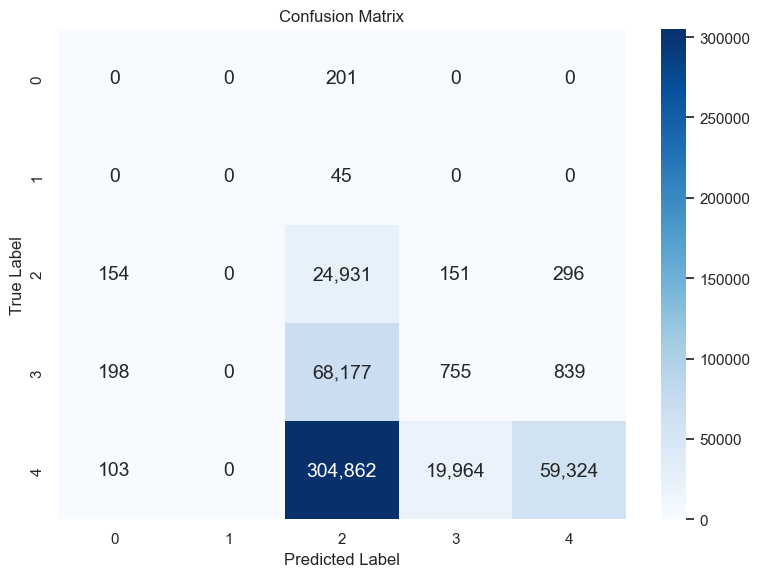

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 역변환
y_true_labels = SegmentEncoder.inverse_transform(y_train_encoded)
y_pred_labels = SegmentEncoder.inverse_transform(y_pred_train)

# 안전하게 라벨 추출
labels = list(np.unique(y_true_labels))

# 혼동 행렬
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

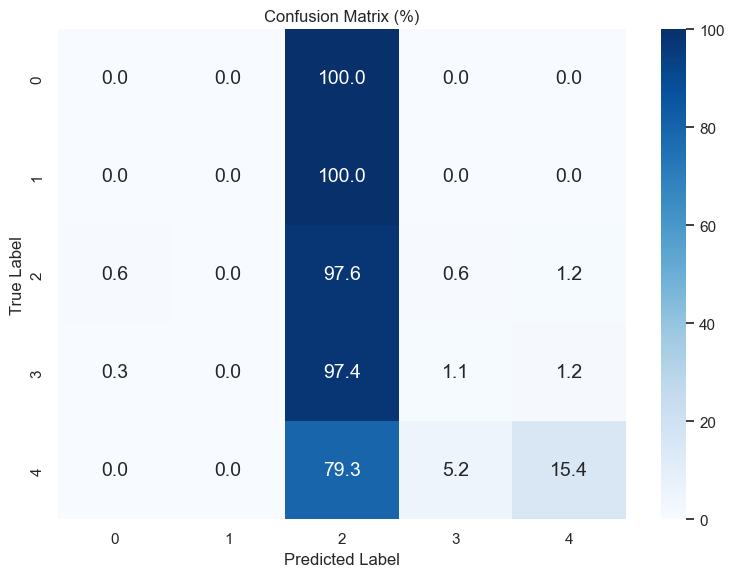

In [28]:
# 비율 기준 혼동행렬 계산
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

cm_percent_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent_df, annot=True, fmt=".1f", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (%)")
plt.tight_layout()
plt.show()
